<a href="https://colab.research.google.com/github/2403a52239-netizen/NLP/blob/main/lab_5_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
tweets_df=pd.read_csv('/content/Tweets.csv')
tweets_df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


Extract Text in Tweet

In [4]:
tweets = tweets_df['text']
print("Extracted tweets (first 5):")
for i, tweet in enumerate(tweets.head()):
    print(f"{i+1}. {tweet}")

Extracted tweets (first 5):
1. @VirginAmerica What @dhepburn said.
2. @VirginAmerica plus you've added commercials to the experience... tacky.
3. @VirginAmerica I didn't today... Must mean I need to take another trip!
4. @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
5. @VirginAmerica and it's a really big bad thing about it


Visulaize Hashtags

In [7]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def extract_hashtags(text):
    hashtags = re.findall(r'#(\w+)', text)
    return [tag.lower() for tag in hashtags]

all_hashtags = [tag for tweet_text in tweets_df['text'] for tag in extract_hashtags(tweet_text)]

hashtag_counts = Counter(all_hashtags)

top_hashtags = hashtag_counts.most_common(10)

print("Top 10 Hashtags:")
for tag, count in top_hashtags:
    print(f"#{tag}: {count}")

Top 10 Hashtags:
#destinationdragons: 81
#fail: 69
#jetblue: 48
#unitedairlines: 45
#customerservice: 36
#usairways: 30
#americanairlines: 27
#neveragain: 27
#united: 26
#usairwaysfail: 26


/tmp/ipython-input-1459314323.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='hashtag', data=hashtags_df, palette='viridis')


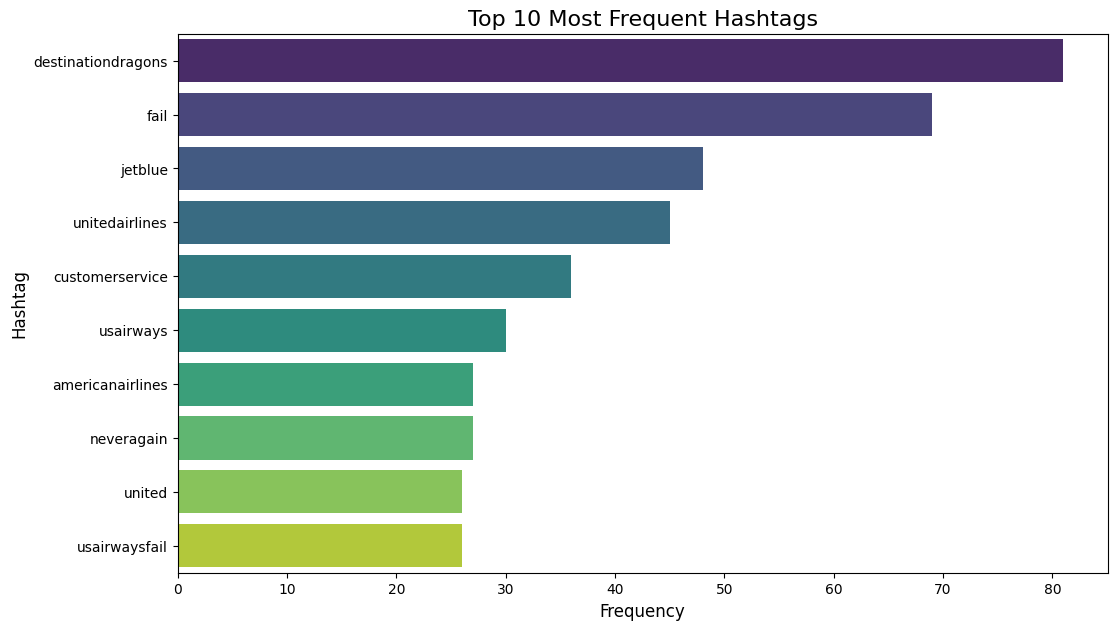

In [8]:
hashtags_df = pd.DataFrame(top_hashtags, columns=['hashtag', 'count'])

plt.figure(figsize=(12, 7))
sns.barplot(x='count', y='hashtag', data=hashtags_df, palette='viridis')
plt.title('Top 10 Most Frequent Hashtags', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Hashtag', fontsize=12)
plt.show()

Clean Text Data

In [9]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub('rhttp\S+', '', text)
    text = re.sub('r@\S+', '', text)
    text = re.sub('r#\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tweets_df['cleaned_text'] = tweets_df['text'].apply(clean_text)

print("First 5 original tweets:")
for i, tweet in enumerate(tweets_df['text'].head()):
    print(f"{i+1}. {tweet}")

print("\nFirst 5 cleaned tweets:")
for i, tweet in enumerate(tweets_df['cleaned_text'].head()):
    print(f"{i+1}. {tweet}")

First 5 original tweets:
1. @VirginAmerica What @dhepburn said.
2. @VirginAmerica plus you've added commercials to the experience... tacky.
3. @VirginAmerica I didn't today... Must mean I need to take another trip!
4. @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
5. @VirginAmerica and it's a really big bad thing about it

First 5 cleaned tweets:
1. virginamerica what dhepburn said
2. virginamerica plus youve added commercials to the experience tacky
3. virginamerica i didnt today must mean i need to take another trip
4. virginamerica its really aggressive to blast obnoxious entertainment in your guests faces amp they have little recourse
5. virginamerica and its a really big bad thing about it


<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-1357510619.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('rhttp\S+', '', text)
/tmp/ipython-input-1357510619.py:6: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('r@\S+', '', text)
/tmp/ipython-input-1357510619.py:7: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('r#\S+', '', text)


Word Tokenization

In [13]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

tokenized_tweets = [word_tokenize(t) for t in tweets_df['cleaned_text']]
print(tokenized_tweets)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[['virginamerica', 'what', 'dhepburn', 'said'], ['virginamerica', 'plus', 'youve', 'added', 'commercials', 'to', 'the', 'experience', 'tacky'], ['virginamerica', 'i', 'didnt', 'today', 'must', 'mean', 'i', 'need', 'to', 'take', 'another', 'trip'], ['virginamerica', 'its', 'really', 'aggressive', 'to', 'blast', 'obnoxious', 'entertainment', 'in', 'your', 'guests', 'faces', 'amp', 'they', 'have', 'little', 'recourse'], ['virginamerica', 'and', 'its', 'a', 'really', 'big', 'bad', 'thing', 'about', 'it'], ['virginamerica', 'seriously', 'would', 'pay', 'a', 'flight', 'for', 'seats', 'that', 'didnt', 'have', 'this', 'playing', 'its', 'really', 'the', 'only', 'bad', 'thing', 'about', 'flying', 'va'], ['virginamerica', 'yes', 'nearly', 'every', 'time', 'i', 'fly', 'vx', 'this', 'ear', 'worm', 'wont', 'go', 'away'], ['virginamerica', 'really', 'missed', 'a', 'prime', 'opportunity', 'for', 'men', 'without', 'hats', 'parody', 'there', 'httpstcomwpggrezp'], ['virginamerica', 'well', 'i', 'didntbut

Stop word removal

In [16]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

filtered_tweets = [[w for w in tokens if w not in stop_words]
                   for tokens in tokenized_tweets]
print(filtered_tweets)

[['virginamerica', 'dhepburn', 'said'], ['virginamerica', 'plus', 'youve', 'added', 'commercials', 'experience', 'tacky'], ['virginamerica', 'didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip'], ['virginamerica', 'really', 'aggressive', 'blast', 'obnoxious', 'entertainment', 'guests', 'faces', 'amp', 'little', 'recourse'], ['virginamerica', 'really', 'big', 'bad', 'thing'], ['virginamerica', 'seriously', 'would', 'pay', 'flight', 'seats', 'didnt', 'playing', 'really', 'bad', 'thing', 'flying', 'va'], ['virginamerica', 'yes', 'nearly', 'every', 'time', 'fly', 'vx', 'ear', 'worm', 'wont', 'go', 'away'], ['virginamerica', 'really', 'missed', 'prime', 'opportunity', 'men', 'without', 'hats', 'parody', 'httpstcomwpggrezp'], ['virginamerica', 'well', 'didntbut'], ['virginamerica', 'amazing', 'arrived', 'hour', 'early', 'youre', 'good'], ['virginamerica', 'know', 'suicide', 'second', 'leading', 'cause', 'death', 'among', 'teens'], ['virginamerica', 'lt', 'pretty', 'graphics', 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
Lemmatization

In [22]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
import pandas as pd
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

lemmatized_tweets = [lemmatize_tokens(tokens) for tokens in filtered_tweets]

print("Filtered tweets (first 5):")
for i, tokens in enumerate(filtered_tweets[:5]):
    print(f"{i+1}. {tokens}")

print("\nLemmatized tweets (first 5):")
for i, tokens in enumerate(lemmatized_tweets[:5]):
    print(f"{i+1}. {tokens}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Filtered tweets (first 5):
1. ['virginamerica', 'dhepburn', 'said']
2. ['virginamerica', 'plus', 'youve', 'added', 'commercials', 'experience', 'tacky']
3. ['virginamerica', 'didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip']
4. ['virginamerica', 'really', 'aggressive', 'blast', 'obnoxious', 'entertainment', 'guests', 'faces', 'amp', 'little', 'recourse']
5. ['virginamerica', 'really', 'big', 'bad', 'thing']

Lemmatized tweets (first 5):
1. ['virginamerica', 'dhepburn', 'said']
2. ['virginamerica', 'plus', 'youve', 'added', 'commercial', 'experience', 'tacky']
3. ['virginamerica', 'didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip']
4. ['virginamerica', 'really', 'aggressive', 'blast', 'obnoxious', 'entertainment', 'guest', 'face', 'amp', 'little', 'recourse']
5. ['virginamerica', 'really', 'big', 'bad', 'thing']


Rejoining (Processed Tweet and Corresponding Label)

In [25]:
import pandas as pd

tweets_df['processed_text'] = lemmatized_tweets
processed_data = tweets_df[['processed_text', 'airline_sentiment']]
print("Rejoined Processed Tweets with Sentiment (first 5 rows):")
display(processed_data.head())

Rejoined Processed Tweets with Sentiment (first 5 rows):


,processed_text,airline_sentiment
0,"[virginamerica, dhepburn, said]",neutral
1,"[virginamerica, plus, youve, added, commercial...",positive
2,"[virginamerica, didnt, today, must, mean, need...",neutral
3,"[virginamerica, really, aggressive, blast, obn...",negative
4,"[virginamerica, really, big, bad, thing]",negative
